# Лабораторная работа 2

In [1]:
from scipy import stats
import numpy
from math import sqrt
from matplotlib import pyplot

n=5
m=3
sigma=2

# уровень доверия
P = 0.95
# квантили - граница
_ = stats.norm.ppf(P, loc=m, scale=sigma)       # нормальное
_ = stats.chi2.ppf(P, df=n)                     # хи-квадрат
_ = stats.t.ppf(P, df=n-1, loc=m, scale=sigma)  # Стьюдента
# квантили - интервал
low, high = stats.norm.interval(P, loc=m, scale=sigma)      # нормальное
low, high = stats.chi2.interval(P, df=n)                    # хи-квадрат
low, high = stats.t.interval(P, df=n-1, loc=m, scale=sigma) # Стьюдента

# реализация
sample = stats.norm.rvs(size=n, loc=m, scale=sigma)

# интервал для математического ожидания (дисперсия известна)
mean = sample.mean()
std = sigma/sqrt(n)
_ = stats.norm.interval(P, loc=mean, scale=std)

# интервал для математического ожидания (дисперсия неизвестна)
mean = sample.mean()
sem = stats.sem(sample)
_ = stats.t.interval(P, df=n-1, loc=mean, scale=sem)

# интервал для ско (математическое ожидание известно)
squares = numpy.sum((sample - m) ** 2)
low, high = stats.chi2.interval(P, df=n)
_, _ = numpy.sqrt(squares/high), numpy.sqrt(squares/low)

# интервал для ско (математическое ожидание неизвестно)
mean = sample.mean()
squares = numpy.sum((sample - mean) ** 2)
low, high = stats.chi2.interval(P, df=n-1)
_, _ = numpy.sqrt(squares/high), numpy.sqrt(squares/low)

## Задача 1

Постройте $k = 20$ реализаций выборки $(\xi_1, \dots, \xi_n)$ объема $n$ из нормального распределения $\mathcal{N}(m, \sigma^2)$, где $m=2$, и для каждой реализации выборки вычислите границы доверительного интервала
$$
    I =
    \left(
        \widehat{m}_1 - y \frac{\sigma}{\sqrt{n}}; \widehat{m}_1 + y \frac{\sigma}{\sqrt{n}}
    \right) , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y = \Phi^{-1}\left( \frac{1 + P_g}{2} \right) ,
$$
где $\Phi(x)$ - функция распределения $\mathcal{N}(0,1)$, используя наборы величин $(n, \sigma, P_g)$, представленные в следующей таблице:

| # | $n$  | $\sigma$ | $P_g$ |
|---|------|----------|-------|
| 1 | 20   | 1        | 0.7   |
| 2 | 20   | 1        | 0.95  |
| 3 | 20   | 1        | 0.999 |
| 4 | 50   | 1        | 0.95  |
| 5 | 500  | 1        | 0.95  |
| 6 | 20   | 3        | 0.95  |
| 7 | 20   | 6        | 0.95  |

1. В системе координат, откладывая по оси абсцисс номер реализации доверительного интервала $I$, а по оси ординат значения левой и правой границ доверительного интервала I, изобразите в виде двух ломанных значения левой и правой границ доверительного интервала $I$ для набора параметров 1. В этой же системе координат проведите прямую параллельную оси абсцисс и пересекающую ось ординат в точке (0, 2), соответствующей значению $m = 2$, использованному при построении реализаций выборки. Подсчитайте количество реализаций доверительного интервала, которые не содержат величину $m = 2$.

2. В одной системе координат изобразите в виде ломанных левые и правые границы реализаций доверительных интервалов для наборов параметров 1, 2 и 3. В двух других системах координат аналогичным образом изобразите левые и правые границы реализаций доверительных интервалов для наборов параметров 2, 4 и 5, а также 2, 6 и 7.

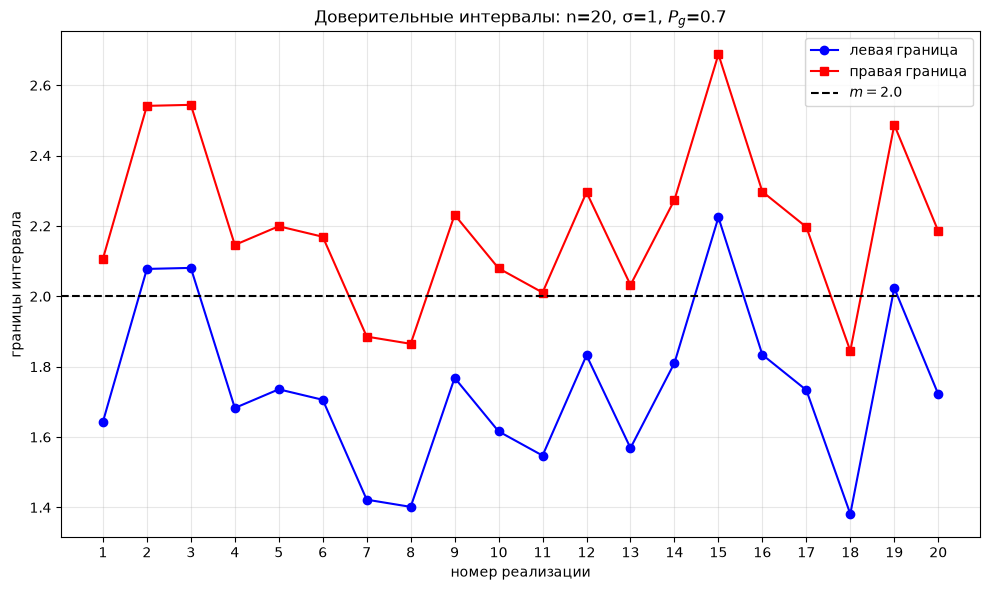

Интервалов, не содержащих m=2.0: 7 из 20


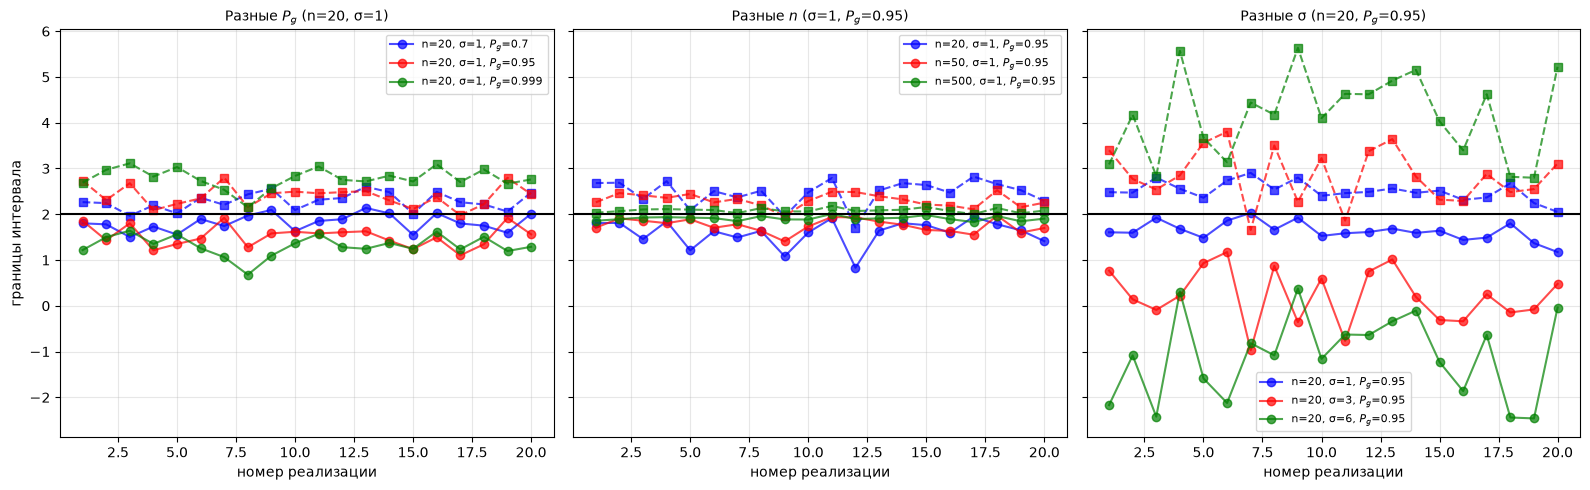

In [ ]:
k = 20

# Таблица параметров
params = [
    (20, 1, 0.7),    # 1
    (20, 1, 0.95),   # 2
    (20, 1, 0.999),  # 3
    (50, 1, 0.95),   # 4
    (500, 1, 0.95),  # 5
    (20, 3, 0.95),   # 6
    (20, 6, 0.95),   # 7
]

m_true = 2.0

def build_intervals(n, sigma, Pg, k=20):
    """Возвращает массивы левых и правых границ для k реализаций."""
    y = stats.norm.ppf((1 + Pg) / 2)
    lows, highs = numpy.zeros(k), numpy.zeros(k)
    for j in range(k):
        sample = stats.norm.rvs(loc=m_true, scale=sigma, size=n)
        m1 = sample.mean()
        lows[j] = m1 - y * sigma / sqrt(n)
        highs[j] = m1 + y * sigma / sqrt(n)
    return lows, highs

# --- Пункт 1: набор параметров 1 ---
lows, highs = build_intervals(*params[0])
x = numpy.arange(1, k + 1)

fig, ax = pyplot.subplots(figsize=(10, 6))
ax.plot(x, lows, 'o-', color='b', label='левая граница')
ax.plot(x, highs, 's-', color='r', label='правая граница')
ax.axhline(m_true, color='k', linestyle='--', linewidth=1.5,
           label=f'$m = {m_true}$')
ax.set_xlabel('номер реализации')
ax.set_ylabel('границы интервала')
ax.set_title(f'Доверительные интервалы: n={params[0][0]}, '
             f'σ={params[0][1]}, $P_g$={params[0][2]}')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

# Подсчёт числа интервалов, НЕ накрывающих m
missed = numpy.sum((lows > m_true) | (highs < m_true))
print(f'Интервалов, не содержащих m={m_true}: {missed} из {k}')

# --- Пункт 2: три системы координат ---
groups = [
    ([params[0], params[1], params[2]], 'Разные $P_g$ (n=20, σ=1)'),
    ([params[1], params[3], params[4]], 'Разные $n$ (σ=1, $P_g$=0.95)'),
    ([params[1], params[5], params[6]], 'Разные σ (n=20, $P_g$=0.95)'),
]

colors = ['b', 'r', 'g']

fig, axes = pyplot.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (group, title) in zip(axes, groups):
    for (n, sigma, Pg), c in zip(group, colors):
        lows, highs = build_intervals(n, sigma, Pg)
        ax.plot(x, lows, 'o-', color=c, alpha=0.7,
                label=f'n={n}, σ={sigma}, $P_g$={Pg}')
        ax.plot(x, highs, 's--', color=c, alpha=0.7)
    ax.axhline(m_true, color='k', linewidth=1.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('номер реализации')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('границы интервала')
pyplot.tight_layout()
pyplot.show()

## Задача 2

Постройте $k = 20$ реализаций выборки $(\xi_1, \dots, \xi_n)$ объема $n = 15$ из нормального распределения $\mathcal{N}(m, \sigma^2)$ для значений $m = 1$ и $\sigma = 2$.

Для всех реализаций выборки вычислите реализации нижней и верхней доверительной границы для $m$ с уровнем доверия доверия $P_g = 0.97$:
$$
    m_l = \widehat{m}_1 - y \frac{\sigma}{\sqrt{n}} , \\
    m_u = \widehat{m}_1 + y \frac{\sigma}{\sqrt{n}} , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y = \Phi^{-1} \left( P_g \right) ,
$$
и доверительного интервала для $m$ с тем же уровнем доверия $P_g = 0.97$:
$$
    \left(
        \widehat{m}_1 - y \frac{\sigma}{\sqrt{n}}; \widehat{m}_1 + y \frac{\sigma}{\sqrt{n}}
    \right) , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y = \Phi^{-1}\left( \frac{1 + P_g}{2} \right) ,
$$
где $\Phi(x)$ - функция распределения $\mathcal{N}(0,1)$.

В одной системе координат изобразите в виде ломанных реализации нижней и верхней доверительных границ, а также значения левой и правой границ доверительного интервала, откладывая по оси абсцисс номер реализации, а по оси ординат реализации границ.

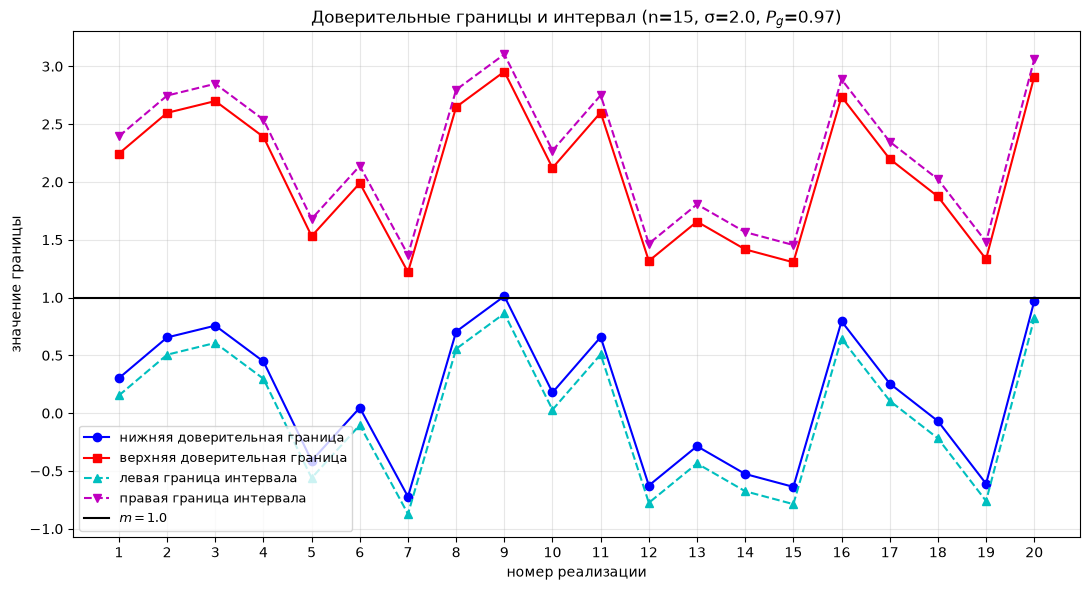

In [3]:
n = 15
m_true, sigma = 1.0, 2.0
Pg = 0.97
k = 20

# Односторонние границы: y = Φ⁻¹(Pg)
y_one = stats.norm.ppf(Pg)
# Двусторонний интервал: y = Φ⁻¹((1+Pg)/2)
y_two = stats.norm.ppf((1 + Pg) / 2)

m_l = numpy.zeros(k)
m_u = numpy.zeros(k)
ci_low = numpy.zeros(k)
ci_high = numpy.zeros(k)

for j in range(k):
    sample = stats.norm.rvs(loc=m_true, scale=sigma, size=n)
    m1 = sample.mean()
    se = sigma / sqrt(n)
    m_l[j] = m1 - y_one * se        # нижняя доверительная граница
    m_u[j] = m1 + y_one * se        # верхняя доверительная граница
    ci_low[j] = m1 - y_two * se     # левая граница интервала
    ci_high[j] = m1 + y_two * se    # правая граница интервала

x = numpy.arange(1, k + 1)
fig, ax = pyplot.subplots(figsize=(11, 6))
ax.plot(x, m_l, 'o-', color='b', label='нижняя доверительная граница')
ax.plot(x, m_u, 's-', color='r', label='верхняя доверительная граница')
ax.plot(x, ci_low, '^--', color='c', label='левая граница интервала')
ax.plot(x, ci_high, 'v--', color='m', label='правая граница интервала')
ax.axhline(m_true, color='k', linewidth=1.5, label=f'$m = {m_true}$')
ax.set_xlabel('номер реализации')
ax.set_ylabel('значение границы')
ax.set_title(f'Доверительные границы и интервал (n={n}, σ={sigma}, $P_g$={Pg})')
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

## Задача 3

Постройте $k = 20$ реализаций выборки $(\xi_1, \dots, \xi_n)$ объема $n = 15$ из нормального распределения $\mathcal{N}(m, \sigma^2)$ для значений $m = 3$ и $\sigma = 1$.

На основе реализаций выборки постройте реализации доверительного интервала для $m$ при известной дисперсии:
$$
    I_1 = \left(
        \widehat{m}_1 - y_1 \frac{\sigma}{\sqrt{n}}; \widehat{m}_1 + y_1 \frac{\sigma}{\sqrt{n}}
    \right) , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y_1 = \Phi^{-1}\left( \frac{1 + P_g}{2} \right) ,
$$
и реализации доверительного интервала для $m$ при неизвестной дисперсии:
$$
    I_2 = \left(
        \widehat{m}_1 - y_2 \sqrt{\frac{\widetilde{\mu}_2}{n}}; \widehat{m}_1 + y_2 \sqrt{\frac{\widetilde{\mu}_2}{n}}
    \right) , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    \widetilde{\mu}_2 = \frac{1}{n-1} \sum \limits_{i=1}^n (\xi_i - \widehat{m}_1)^2 , \\
    y_2 = F_{T(n-1)}^{-1}\left( \frac{1 + P_g}{2} \right) ,
$$
где $F_{T(n-1)}(x)$ - функция распределения $T(n-1)$, распределения Стьюдента с $n-1$ степенью свободы, с одинаковым уровнем доверия $P_g = 0.95$.

В одной системе координат изобразите в виде ломанных левые и правые границы реализаций доверительных интервалов. Вычислите среднюю «длину» реализаций доверительного интервала $I_1$ и сравните с «длиной» реализаций доверительного интервала $I_2$, вычислите отношение «длин».

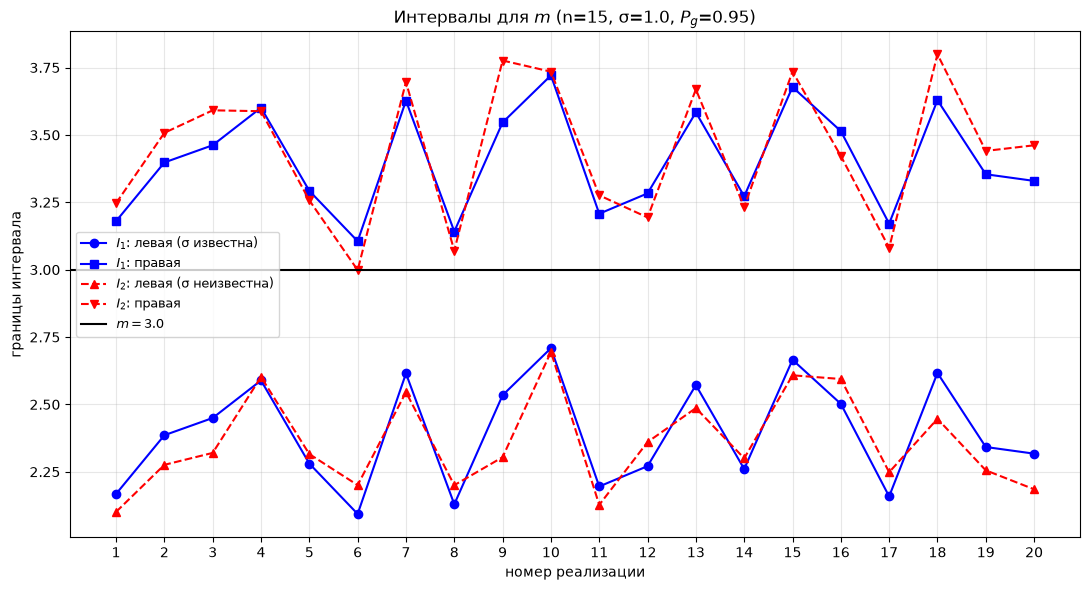

Средняя длина I1 (σ известна):   1.0121
Средняя длина I2 (σ неизвестна): 1.0803
Отношение длин I2/I1:            1.0674


In [4]:
n = 15
m_true, sigma = 3.0, 1.0
Pg = 0.95
k = 20

y1 = stats.norm.ppf((1 + Pg) / 2)               # известная дисперсия
y2 = stats.t.ppf((1 + Pg) / 2, df=n - 1)        # неизвестная дисперсия

I1_low = numpy.zeros(k); I1_high = numpy.zeros(k)
I2_low = numpy.zeros(k); I2_high = numpy.zeros(k)

for j in range(k):
    sample = stats.norm.rvs(loc=m_true, scale=sigma, size=n)
    m1 = sample.mean()
    mu2 = sample.var(ddof=1)                    # несмещённая дисперсия
    
    se1 = sigma / sqrt(n)
    I1_low[j] = m1 - y1 * se1
    I1_high[j] = m1 + y1 * se1
    
    se2 = sqrt(mu2 / n)
    I2_low[j] = m1 - y2 * se2
    I2_high[j] = m1 + y2 * se2

x = numpy.arange(1, k + 1)
fig, ax = pyplot.subplots(figsize=(11, 6))
ax.plot(x, I1_low, 'o-', color='b', label='$I_1$: левая (σ известна)')
ax.plot(x, I1_high, 's-', color='b', label='$I_1$: правая')
ax.plot(x, I2_low, '^--', color='r', label='$I_2$: левая (σ неизвестна)')
ax.plot(x, I2_high, 'v--', color='r', label='$I_2$: правая')
ax.axhline(m_true, color='k', linewidth=1.5, label=f'$m = {m_true}$')
ax.set_xlabel('номер реализации')
ax.set_ylabel('границы интервала')
ax.set_title(f'Интервалы для $m$ (n={n}, σ={sigma}, $P_g$={Pg})')
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

# Средние длины
len1 = numpy.mean(I1_high - I1_low)
len2 = numpy.mean(I2_high - I2_low)
print(f'Средняя длина I1 (σ известна):   {len1:.4f}')
print(f'Средняя длина I2 (σ неизвестна): {len2:.4f}')
print(f'Отношение длин I2/I1:            {len2 / len1:.4f}')

## Задача 4

Постройте $k = 20$ реализаций выборки $(\xi_1, \dots, \xi_n)$ объёма $n=30$ из нормального распределения $\mathcal{N}(m, \sigma^2)$ для $m = 1$ и $\sigma = 2$.

Вычислите реализации доверительного интервала для среднеквадратического отклонения $\sigma$ при известном математическом ожидании $m$:
$$
    I_1 = \left( \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - m)^2}{y_2}} ; \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - m)^2}{y_1}} \right) , \\
    y_1 = F_{\chi^2(n)}^{-1} \left( \frac{1 - P_g}{2} \right) , \\
    y_2 = F_{\chi^2(n)}^{-1} \left( \frac{1 + P_g}{2} \right) ,
$$
где $F_{\chi^2(n)}$ - функция распределения $\chi^2(n)$, распределения хи-квадрат с $n$ степенями свободы, и доверительного интервала для среднеквадратического отклонения $\sigma$ при неизвестном математическом ожидании $m$:
$$
    I_2 = \left( \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - \widehat{m}_1)^2}{y_2}} ; \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - \widehat{m}_1)^2}{y_1}} \right) , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y_1 = F_{\chi^2(n-1)}^{-1} \left( \frac{1 - P_g}{2} \right) , \\
    y_2 = F_{\chi^2(n-1)}^{-1} \left( \frac{1 + P_g}{2} \right) ,
$$
где $F_{\chi^2(n-1)}$ - функция распределения $\chi^2(n-1)$, распределения хи-квадрат с $n-1$ степенью свободы, с уровнем доверия $P_g = 0.95$.

В одной системе координат постройте в виде ломанных левые и правые границы реализаций доверительных интервалов. Вычислите среднюю «длину» реализаций доверительного интервала $I_1$, среднюю «длину» реализаций доверительного интервала $I_2$ и вычислите отношение средних «длин».

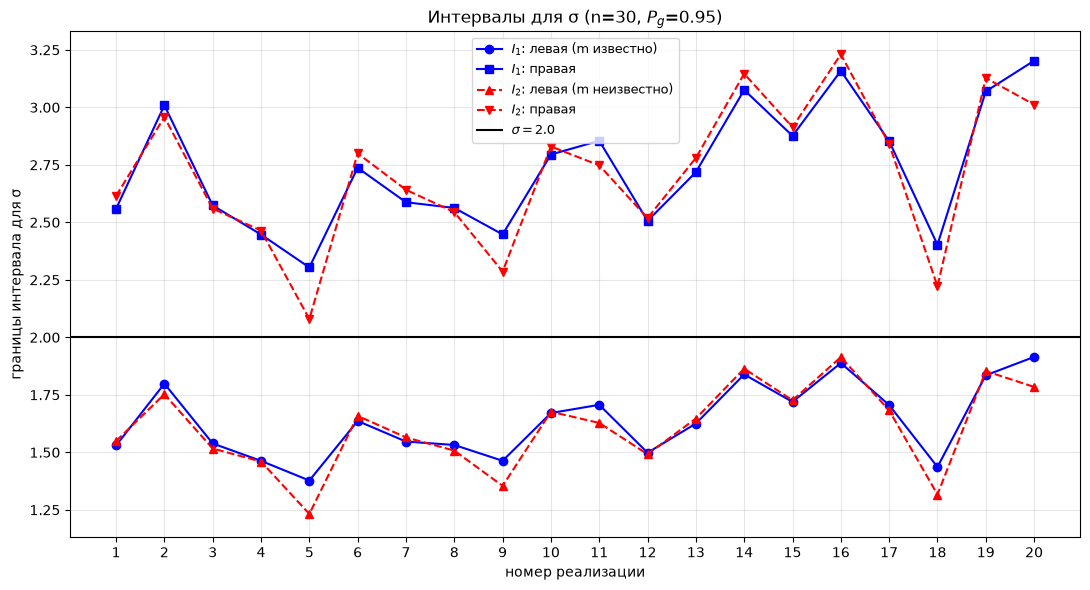

Средняя длина I1 (m известно):   1.1007
Средняя длина I2 (m неизвестно): 1.1069
Отношение средних длин I2/I1:    1.0056


In [5]:
n = 30
m_true, sigma = 1.0, 2.0
Pg = 0.95
k = 20

# Квантили хи-квадрат
y1_known = stats.chi2.ppf((1 - Pg) / 2, df=n)       # нижний
y2_known = stats.chi2.ppf((1 + Pg) / 2, df=n)       # верхний
y1_unk = stats.chi2.ppf((1 - Pg) / 2, df=n - 1)
y2_unk = stats.chi2.ppf((1 + Pg) / 2, df=n - 1)

I1_low = numpy.zeros(k); I1_high = numpy.zeros(k)
I2_low = numpy.zeros(k); I2_high = numpy.zeros(k)

for j in range(k):
    sample = stats.norm.rvs(loc=m_true, scale=sigma, size=n)
    m1 = sample.mean()
    
    S_known = numpy.sum((sample - m_true) ** 2)     # m известно
    S_unk = numpy.sum((sample - m1) ** 2)           # m неизвестно
    
    I1_low[j] = sqrt(S_known / y2_known)
    I1_high[j] = sqrt(S_known / y1_known)
    I2_low[j] = sqrt(S_unk / y2_unk)
    I2_high[j] = sqrt(S_unk / y1_unk)

x = numpy.arange(1, k + 1)
fig, ax = pyplot.subplots(figsize=(11, 6))
ax.plot(x, I1_low, 'o-', color='b', label='$I_1$: левая (m известно)')
ax.plot(x, I1_high, 's-', color='b', label='$I_1$: правая')
ax.plot(x, I2_low, '^--', color='r', label='$I_2$: левая (m неизвестно)')
ax.plot(x, I2_high, 'v--', color='r', label='$I_2$: правая')
ax.axhline(sigma, color='k', linewidth=1.5, label=f'$\\sigma = {sigma}$')
ax.set_xlabel('номер реализации')
ax.set_ylabel('границы интервала для σ')
ax.set_title(f'Интервалы для σ (n={n}, $P_g$={Pg})')
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

len1 = numpy.mean(I1_high - I1_low)
len2 = numpy.mean(I2_high - I2_low)
print(f'Средняя длина I1 (m известно):   {len1:.4f}')
print(f'Средняя длина I2 (m неизвестно): {len2:.4f}')
print(f'Отношение средних длин I2/I1:    {len2 / len1:.4f}')

## Задача 5

Постройте $k = 20$ реализаций выборки $(\xi_1, \dots, \xi_n)$ объема $n = 25$ из нормального распределения $\mathcal{𝑁}(m, \sigma^2)$, для $m = 4$ и $\sigma = 2$.

Вычислите реализации нижней доверительной границы для среднеквадратического отклонения $\sigma$ при известном математическом ожидании $m$:
$$
    \sigma_{1,l} = \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - m)^2}{y}} , \\
    y = F_{\chi^2(n)}^{-1} \left( P_g \right),
$$
и верхней доверительной границы для среднеквадратического отклонения $\sigma$ при известном математическом ожидании $m$:
$$
    \sigma_{1,u} = \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - m)^2}{y}} , \\
    y = F_{\chi^2(n)}^{-1} \left( 1 - P_g \right),
$$
где $F_{\chi^2(n)}$ - функция распределения $\chi^2(n)$, распределения хи-квадрат с $n$ степенями свободы, с уровнем доверия $P_g = 0.97$.

Вычислите реализации нижней доверительной границы для среднеквадратического отклонения $\sigma$ при неизвестном математическом ожидании $m$:
$$
    \sigma_{2,l} = \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - \widehat{m}_1)^2}{y}} , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y = F_{\chi^2(n-1)}^{-1} \left( P_g \right),
$$
и верхней доверительной границы для среднеквадратического отклонения $\sigma$ при неизвестном математическом ожидании $m$:
$$
    \sigma_{2,u} = \sqrt{\frac{\sum \limits_{i=1}^n (\xi_i - \widehat{m})^2}{y}} , \\
    \widehat{m}_1 = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y = F_{\chi^2(n-1)}^{-1} \left( 1 - P_g \right),
$$
где $F_{\chi^2(n-1)}$ - функция распределения $\chi^2(n-1)$, распределения хи-квадрат с $n-1$ степенями свободы, с уровнем доверия $P_g = 0.97$.

В одной системе координат постройте в виде ломанных реализации всех доверительных границ.

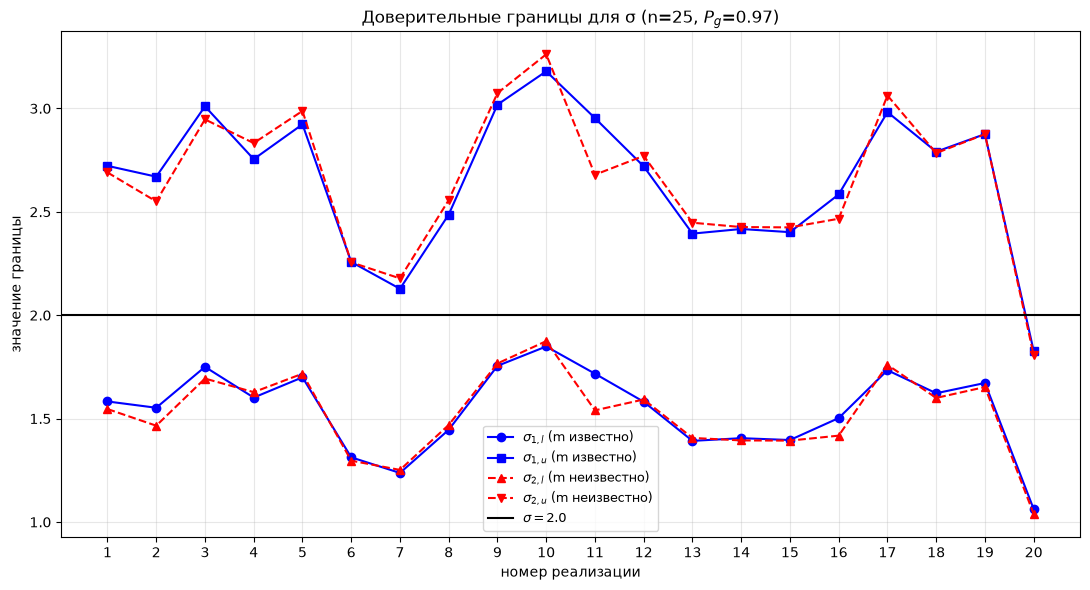

In [6]:
n = 25
m_true, sigma = 4.0, 2.0
Pg = 0.97
k = 20

# Нижняя и верхняя границы (односторонние) — квантили уровня Pg и 1-Pg
y_lo_known = stats.chi2.ppf(Pg, df=n)
y_hi_known = stats.chi2.ppf(1 - Pg, df=n)
y_lo_unk = stats.chi2.ppf(Pg, df=n - 1)
y_hi_unk = stats.chi2.ppf(1 - Pg, df=n - 1)

s1_l = numpy.zeros(k); s1_u = numpy.zeros(k)
s2_l = numpy.zeros(k); s2_u = numpy.zeros(k)

for j in range(k):
    sample = stats.norm.rvs(loc=m_true, scale=sigma, size=n)
    m1 = sample.mean()
    
    S_known = numpy.sum((sample - m_true) ** 2)
    S_unk = numpy.sum((sample - m1) ** 2)
    
    s1_l[j] = sqrt(S_known / y_lo_known)
    s1_u[j] = sqrt(S_known / y_hi_known)
    s2_l[j] = sqrt(S_unk / y_lo_unk)
    s2_u[j] = sqrt(S_unk / y_hi_unk)

x = numpy.arange(1, k + 1)
fig, ax = pyplot.subplots(figsize=(11, 6))
ax.plot(x, s1_l, 'o-', color='b', label='$\\sigma_{1,l}$ (m известно)')
ax.plot(x, s1_u, 's-', color='b', label='$\\sigma_{1,u}$ (m известно)')
ax.plot(x, s2_l, '^--', color='r', label='$\\sigma_{2,l}$ (m неизвестно)')
ax.plot(x, s2_u, 'v--', color='r', label='$\\sigma_{2,u}$ (m неизвестно)')
ax.axhline(sigma, color='k', linewidth=1.5, label=f'$\\sigma = {sigma}$')
ax.set_xlabel('номер реализации')
ax.set_ylabel('значение границы')
ax.set_title(f'Доверительные границы для σ (n={n}, $P_g$={Pg})')
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

## Задача 6

Постройте $k = 15$ реализаций выборки $(\xi_1, \dots, \xi_n)$ из распределения Бернулли $Be(p)$ с вероятностью $p = 0.4$ объема $n = 20$.

Вычислите реализации доверительных интервалов $I_1$ и $I_2$:
$$
    I_1
    = \left( \overline{p} - y \sqrt{\frac{\overline{p}(1-\overline{p})}{n}} ; \overline{p} + y \sqrt{\frac{\overline{p}(1-\overline{p})}{n}} \right) , \\
    I_2
    = \left( \overline{p} - y \sqrt{\frac{1}{n}} ; \overline{p} + y \sqrt{\frac{1}{n}} \right) , \\
    \overline{p} = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y = \Phi^{-1}\left( \frac{1 + P_g}{2} \right),
$$
где $\Phi(x)$ - функция распределения $\mathcal{N}(0,1)$, для уровня доверия $P_g = 0.95$.

Изобразите в одной системе координат в виде ломанных левые и правые границы вычисленных реализаций доверительных интервалов.

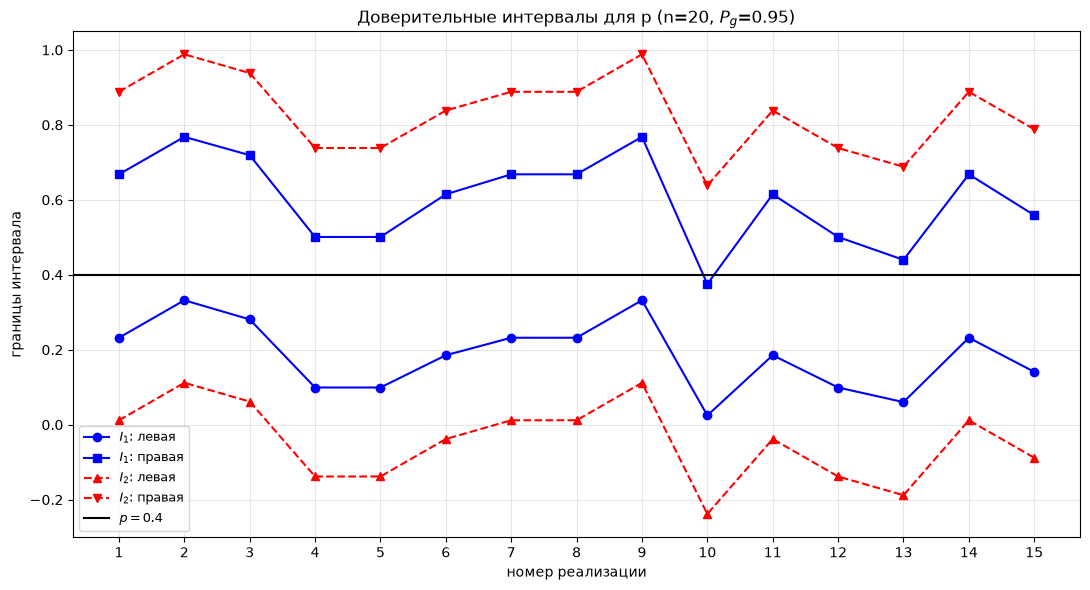

In [7]:
n = 20
p_true = 0.4
Pg = 0.95
k = 15

y = stats.norm.ppf((1 + Pg) / 2)

I1_low = numpy.zeros(k); I1_high = numpy.zeros(k)
I2_low = numpy.zeros(k); I2_high = numpy.zeros(k)

for j in range(k):
    sample = stats.bernoulli.rvs(p_true, size=n)
    p_hat = sample.mean()
    
    se1 = sqrt(p_hat * (1 - p_hat) / n)     # «правильная» оценка дисперсии
    se2 = sqrt(1 / n)                       # «грубая» оценка (максимальная)
    
    I1_low[j] = p_hat - y * se1
    I1_high[j] = p_hat + y * se1
    I2_low[j] = p_hat - y * se2
    I2_high[j] = p_hat + y * se2

x = numpy.arange(1, k + 1)
fig, ax = pyplot.subplots(figsize=(11, 6))
ax.plot(x, I1_low, 'o-', color='b', label='$I_1$: левая')
ax.plot(x, I1_high, 's-', color='b', label='$I_1$: правая')
ax.plot(x, I2_low, '^--', color='r', label='$I_2$: левая')
ax.plot(x, I2_high, 'v--', color='r', label='$I_2$: правая')
ax.axhline(p_true, color='k', linewidth=1.5, label=f'$p = {p_true}$')
ax.set_xlabel('номер реализации')
ax.set_ylabel('границы интервала')
ax.set_title(f'Доверительные интервалы для p (n={n}, $P_g$={Pg})')
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

## Задача 7

Постройте $k = 10$ реализаций выборки $(\xi_1, \dots, \xi_n)$ объема $n = 20$ из распределения $\mathcal{P}(\lambda)$ с параметром $\lambda = 2$ и вычислите реализации нижней и верхней доверительных границ параметра $\lambda$ с уровнем доверия $P_g = 0.95$:
$$
    \lambda_l = \widehat{\lambda} - y \sqrt{\frac{\widehat{\lambda}}{n}} , \\
    \lambda_u = \widehat{\lambda} + y \sqrt{\frac{\widehat{\lambda}}{n}} , \\
    \widehat{\lambda} = \frac{1}{n} \sum \limits_{i=1}^n \xi_i , \\
    y = \Phi^{-1}\left( P_g \right),
$$
где $\Phi(x)$ - функция распределения $\mathcal{N}(0,1)$.

Изобразите в одной системе координат в виде ломанных вычисленные реализации доверительных границ.

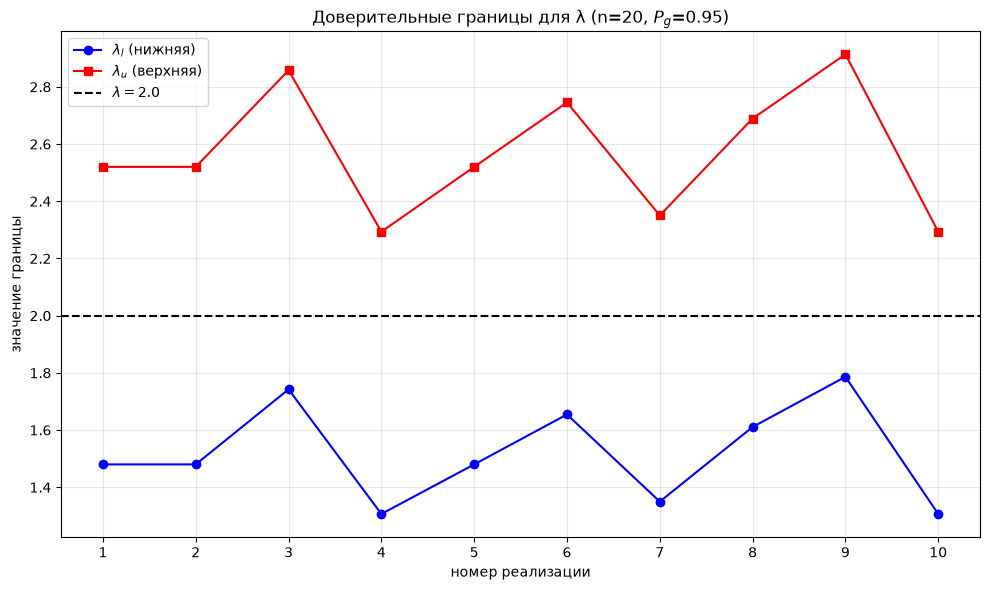

In [8]:
n = 20
lam_true = 2.0
Pg = 0.95
k = 10

y = stats.norm.ppf(Pg)      # односторонняя (по условию)

lam_l = numpy.zeros(k)
lam_u = numpy.zeros(k)

for j in range(k):
    sample = stats.poisson.rvs(lam_true, size=n)
    lam_hat = sample.mean()
    se = sqrt(lam_hat / n)
    lam_l[j] = lam_hat - y * se
    lam_u[j] = lam_hat + y * se

x = numpy.arange(1, k + 1)
fig, ax = pyplot.subplots(figsize=(10, 6))
ax.plot(x, lam_l, 'o-', color='b', label='$\\lambda_l$ (нижняя)')
ax.plot(x, lam_u, 's-', color='r', label='$\\lambda_u$ (верхняя)')
ax.axhline(lam_true, color='k', linestyle='--', linewidth=1.5,
           label=f'$\\lambda = {lam_true}$')
ax.set_xlabel('номер реализации')
ax.set_ylabel('значение границы')
ax.set_title(f'Доверительные границы для λ (n={n}, $P_g$={Pg})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

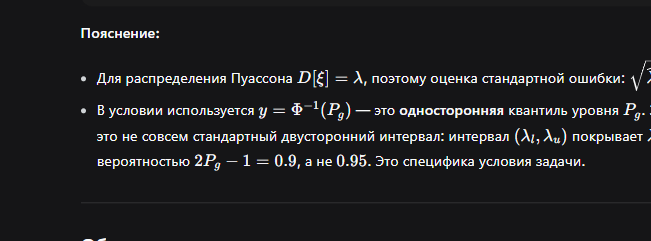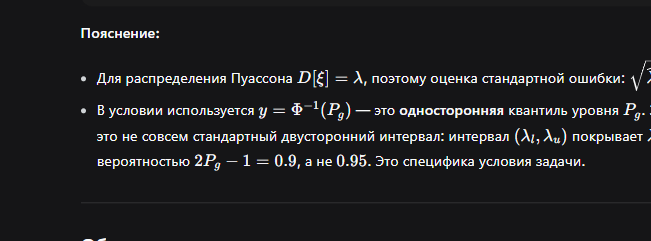](attachment:image.png)](attachment:image.png)](attachment:image.png)](attachment:image.png)